# Machine and Deep Learning for DDoS Detection
### Marcos V. O. Assis (mvoassis@gmail.com)
***

> ## Published Results:

* *A GRU deep learning system against attacks in software defined networks*

* https://doi.org/10.1016/j.jnca.2020.102942



* \***Update - 06/2022** - improved detection results through better data cleaning process. Updated results on Git. 

> ## Objectives

1. Evaluate different Machine and Deep Learning methods for anomaly detection.
2. Detection of Distributed Denial of Service Attacks

> ## Dataset

* CIC-DDoS2019 - https://www.unb.ca/cic/datasets/ddos-2019.html

> ## Evaluated Methods

* Gated Recurrent Units (GRU)
* Long-Short Term Memory (LSTM)
* Convolutional Neural Network (CNN)
* Deep Neural Network (DNN)
* Support Vector Machine (SVM)
* Logistic Regression (LR)
* Gradient Descent (GD)
* k Nearest Neighbors (kNN)

> ## Environment Config.

* Python 3.7.13
* Numpy 1.16.4
* Scikit-learn 0.21.2
* Pandas 0.24.2
* Tensorflow 1.14.0
* Keras 2.2.4
* Matplotlib 3.1.0
* Seaborn 0.11.2

***

# Importing and treating CIC-DDoS-2019

In [1]:
import pandas as pd
import numpy as np
from sklearn.utils import resample
from sklearn import preprocessing

## Defining functions to load files and downsample them

As this research aims to develop a binary detector (Attack or Normal), we should balance the dataset between these two classes. However, CIC-DDOS2019 has few normal flows in it. Thus, downsampling is necessary.

For the downsampling process, we allow anomalous flows to be "mult" times bigger than normal flows. This approach aims to reduce class disbalance while preventing information losses on attack flows (when the number of attack flows is downsampled to the number of normal ones, ML models could not fit appropriately).  

**How it Works:**
Calculates the total number of lines and determines which rows to skip (if the file exceeds num_samples).
Reads the CSV file in large chunks (each of size 500,000 rows).

**For each chunk:**
Separates benign and anomalous flows.
Downsamples the anomalous flows in the same way as load_file.
Collects the processed chunks.
Finally, concatenates all the chunks from both classes to create the final DataFrame.

In [2]:
import pandas as pd
import random
from sklearn.utils import resample

mult = 5 # is a multiplier (set to 5) to control the target size of the downsampled anomaly class.
num_samples = 5000  # Variable to control the number of rows to read

def load_file(path):
    # Count total lines in the file (excluding header)
    total_lines = sum(1 for _ in open(path)) - 1  

    # Ensure at most `num_samples` rows are read randomly
    if total_lines > num_samples:
        skip_rows = sorted(random.sample(range(1, total_lines + 1), total_lines - num_samples))
    else:
        skip_rows = None  # Read entire file if it's smaller than `num_samples`

    data = pd.read_csv(path, skiprows=skip_rows, sep=',', low_memory=False)

    is_benign = data[' Label'] == 'BENIGN'
    flows_ok = data[is_benign]
    flows_ddos_full = data[~is_benign]
    
    sizeDownSample = len(flows_ok) * mult  # Target size for anomalous data
    
    # Downsample majority class
    if sizeDownSample < len(flows_ddos_full): 
        flows_ddos_reduced = resample(
            flows_ddos_full,
            replace=False,
            n_samples=sizeDownSample,
            random_state=27
        )
    else:
        flows_ddos_reduced = flows_ddos_full

    final_df = pd.concat([flows_ok, flows_ddos_reduced])

    return final_df


def load_huge_file(path):
    total_lines = sum(1 for _ in open(path)) - 1  

    if total_lines > num_samples:
        skip_rows = sorted(random.sample(range(1, total_lines + 1), total_lines - num_samples))
    else:
        skip_rows = None  

    df_chunk = pd.read_csv(path, skiprows=skip_rows, chunksize=500000, low_memory=False)
    
    chunk_list_ok = []  
    chunk_list_ddos = [] 

    for chunk in df_chunk:  
        is_benign = chunk[' Label'] == 'BENIGN'
        flows_ok = chunk[is_benign]
        flows_ddos_full = chunk[~is_benign]
        
        if (len(flows_ok) * mult) < len(flows_ddos_full): 
            sizeDownSample = len(flows_ok) * mult  
            
            flows_ddos_reduced = resample(
                flows_ddos_full,
                replace=False,
                n_samples=sizeDownSample,
                random_state=27
            )
        else:
            flows_ddos_reduced = flows_ddos_full
            
        chunk_list_ok.append(flows_ok)
        chunk_list_ddos.append(flows_ddos_reduced)
        
    flows_ok = pd.concat(chunk_list_ok)
    flows_ddos = pd.concat(chunk_list_ddos)

    final_df = pd.concat([flows_ok, flows_ddos])

    return final_df


## Loading CIC-DDoS2019 - Day 1 (training)

In [3]:
# Load first file
flows = load_huge_file('/kaggle/input/cic-ddos2019-30gb-full-dataset-csv-files/01-12/TFTP.csv')
print('file 1 loaded')

# List of remaining files
files = [
    "DrDoS_LDAP.csv", "DrDoS_MSSQL.csv", "DrDoS_NetBIOS.csv",
    "DrDoS_NTP.csv", "DrDoS_SNMP.csv", "DrDoS_SSDP.csv",
    "DrDoS_UDP.csv", "Syn.csv", "DrDoS_DNS.csv", "UDPLag.csv"
]

# Process each file
for i, file in enumerate(files, start=2):
    df = load_file(f'/kaggle/input/cic-ddos2019-30gb-full-dataset-csv-files/01-12/{file}')
    
    # Concatenate new file data
    flows = pd.concat([flows, df], ignore_index=True)
    
    print(f'file {i} loaded')

# Save to CSV
flows.to_csv('/kaggle/working/export_dataframe.csv', index=False, header=True)

# Delete large variable
del flows


file 1 loaded
file 2 loaded
file 3 loaded
file 4 loaded
file 5 loaded
file 6 loaded
file 7 loaded
file 8 loaded
file 9 loaded
file 10 loaded
file 11 loaded


## Loading CIC-DDoS2019 - Day 2 (testing)

In [4]:
import pandas as pd

# File paths
base_path = "/kaggle/input/cic-ddos2019-30gb-full-dataset-csv-files/03-11/"
files = ["LDAP.csv", "MSSQL.csv", "NetBIOS.csv", "Portmap.csv", "Syn.csv"]
# Uncomment if fixed
# files += ["UDP.csv", "UDPLag.csv"]  

# Load first file
flows = load_file(base_path + files[0])  # Expecting ONE DataFrame
print('file 1 loaded')

# Load remaining files
for i, file in enumerate(files[1:], start=2):
    df = load_file(base_path + file)  # Expecting ONE DataFrame
    
    # Concatenate the new file data
    flows = pd.concat([flows, df], ignore_index=True)

    print(f'file {i} loaded')

# Save to CSV
flows.to_csv('/kaggle/working/export_tests.csv', index=False, header=True)

# Free memory
del flows, df


file 1 loaded
file 2 loaded
file 3 loaded
file 4 loaded
file 5 loaded


## CIC-DDoS2019 Data Processing

In [5]:
import pandas as pd
import numpy as np
import hashlib

# Load dataset
samples = pd.read_csv('/kaggle/working/export_dataframe.csv', sep=',')

# Function to convert string to numeric hash
def string2numeric_hash(text):
    return int(hashlib.md5(text.encode()).hexdigest()[:8], 16)

# Replace infinite values
samples = samples.replace(['Infinity', np.inf], 0)

# Convert numerical columns safely
samples[' Flow Packets/s'] = pd.to_numeric(samples[' Flow Packets/s'], errors='coerce').fillna(0)
samples['Flow Bytes/s'] = pd.to_numeric(samples['Flow Bytes/s'], errors='coerce').fillna(0)

# Convert labels to numeric
samples[' Label'] = samples[' Label'].replace({
    'BENIGN': 0, 'DrDoS_DNS': 1, 'DrDoS_LDAP': 1, 'DrDoS_MSSQL': 1,
    'DrDoS_NTP': 1, 'DrDoS_NetBIOS': 1, 'DrDoS_SNMP': 1, 'DrDoS_SSDP': 1,
    'DrDoS_UDP': 1, 'Syn': 1, 'TFTP': 1, 'UDP-lag': 1, 'WebDDoS': 1
}).astype(int)

# Ensure no NaN timestamps before splitting
samples[' Timestamp'] = samples[' Timestamp'].fillna('1970-01-01 00:00:00.000000')

# Process timestamps
colunaTime = samples[' Timestamp'].str.split(' ', n=1, expand=True)
colunaTime.columns = ['dia', 'horas']
colunaTime = colunaTime['horas'].str.split('.', n=1, expand=True)
colunaTime.columns = ['horas', 'milisec']
samples[' Timestamp'] = colunaTime['horas'].apply(string2numeric_hash)

# Drop unnecessary columns
samples.drop(columns=[' Source IP', ' Destination IP', 'Flow ID', 'SimillarHTTP', 'Unnamed: 0'], inplace=True)

# Save processed dataset
samples.to_csv('/kaggle/working/export_dataframe_proc.csv', index=False, header=True)

print('Training data processed successfully!')

Training data processed successfully!


<ipython-input-5-53e61ebe6a31>:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  samples[' Label'] = samples[' Label'].replace({


In [6]:
import pandas as pd
import numpy as np
import hashlib

# Load dataset
tests = pd.read_csv('/kaggle/working/export_tests.csv', sep=',')

# Function to convert string to numeric hash
def string2numeric_hash(text):
    return int(hashlib.md5(text.encode()).hexdigest()[:8], 16)

# Replace infinite values
tests = tests.replace(['Infinity', np.inf], 0)

# Convert numerical columns safely
tests[' Flow Packets/s'] = pd.to_numeric(tests[' Flow Packets/s'], errors='coerce').fillna(0)
tests['Flow Bytes/s'] = pd.to_numeric(tests['Flow Bytes/s'], errors='coerce').fillna(0)

# Convert labels to numeric
tests[' Label'] = tests[' Label'].replace({
    'BENIGN': 0, 'LDAP': 1, 'NetBIOS': 1, 'MSSQL': 1,
    'Portmap': 1, 'Syn': 1
}).astype(int)

# Ensure no NaN timestamps before splitting
tests[' Timestamp'] = tests[' Timestamp'].fillna('1970-01-01 00:00:00.000000')

# Process timestamps
colunaTime = tests[' Timestamp'].str.split(' ', n=1, expand=True)
colunaTime.columns = ['dia', 'horas']
colunaTime = colunaTime['horas'].str.split('.', n=1, expand=True)
colunaTime.columns = ['horas', 'milisec']
tests[' Timestamp'] = colunaTime['horas'].apply(string2numeric_hash)

# Drop unnecessary columns
tests.drop(columns=[' Source IP', ' Destination IP', 'Flow ID', 'SimillarHTTP', 'Unnamed: 0'], inplace=True)

# Save processed dataset
tests.to_csv('/kaggle/working/export_tests_proc.csv', index=False, header=True)

print('Test data processed successfully!')

Test data processed successfully!


<ipython-input-6-77d02209dd71>:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tests[' Label'] = tests[' Label'].replace({


## Methods implementation

Importing required library

In [7]:
# Import required libraries
from keras.models import Sequential

from keras.layers import Dense,GRU,Embedding,Dropout,Flatten,Conv1D,MaxPooling1D,LSTM
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier

### Gated Recurrent Units (GRU)

In [8]:
#input_size
# -> CIC-DDoS2019 82
# -> CIC-IDS2018 78

def GRU_model(input_size):
   
    # Initialize the constructor
    model = Sequential()
    
    model.add(GRU(32, input_shape=(input_size,1), return_sequences=False)) #
    model.add(Dropout(0.5))    
    model.add(Dense(10, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    
    model.build()
    print(model.summary())
    
    return model

### Convolutional Neural Network (CNN)

In [9]:
def CNN_model(input_size):
   
    # Initialize the constructor
    model = Sequential()
    
    model.add(Conv1D(filters=64, kernel_size=8, activation='relu', input_shape=(input_size,1)))
    model.add(MaxPooling1D(2))
    model.add(Conv1D(filters=32, kernel_size=16, activation='relu'))
    model.add(MaxPooling1D(2))
    model.add(Conv1D(filters=16, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(2))
    
    model.add(Dropout(0.5))

    model.add(Flatten())
    model.add(Dense(10, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    
    print(model.summary())
    
    return model

### Long-Short Term Memory (LSTM)

In [10]:
def LSTM_model(input_size):
   
    # Initialize the constructor
    model = Sequential()
    
    model.add(LSTM(32,input_shape=(input_size,1), return_sequences=False))
    model.add(Dropout(0.5))    
    model.add(Dense(10, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    
    print(model.summary())
    
    return model

### Deep Neural Network (DNN)

In [11]:
def DNN_model(input_size):
   
    # Initialize the constructor
    model = Sequential()
    
    model.add(Dense(2, activation='relu', input_shape=(input_size,)))
    #model.add(Dense(100, activation='relu'))   
    #model.add(Dense(40, activation='relu'))
    #model.add(Dense(10, activation='relu'))
    #model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    
    print(model.summary())
    
    return model

### Support Vector Machine (SVM)

In [12]:
def SVM():
    return SVC(kernel='linear')

### Logistic Regression (LR)

In [13]:
def LR():
    return LogisticRegression()

### Gradient Descent (GD)

In [14]:
def GD():
    return SGDClassifier()

### k Nearest Neighbors (kNN)

In [15]:
def kNN():
    return KNeighborsClassifier(n_neighbors=3, n_jobs=-1)

# Auxiliar Functions

Implementation of auxiliar functions, such as testing, compiling/training, 3d reshape, etc. 

### train_test(samples)
> Receives a group of samples and split it in train/test sets.

In [16]:
def train_test(samples):
    # Import `train_test_split` from `sklearn.model_selection`
    from sklearn.model_selection import train_test_split
    import numpy as np
    
    # Specify the data 
    X=samples.iloc[:,0:(samples.shape[1]-1)]
    
    # Specify the target labels and flatten the array
    #y= np.ravel(amostras.type)
    y= samples.iloc[:,-1]
    
    # Split the data up in train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
    
    return X_train, X_test, y_train, y_test


### normalize_data(X_train,X_test)

> Normalize data between -1 and 1

In [17]:
# normalize input data

def normalize_data(X_train,X_test):
    # Import `StandardScaler` from `sklearn.preprocessing`
    from sklearn.preprocessing import StandardScaler,MinMaxScaler
    
    # Define the scaler 
    #scaler = StandardScaler().fit(X_train)
    scaler = MinMaxScaler(feature_range=(-1, 1)).fit(X_train)
    
    # Scale the train set
    X_train = scaler.transform(X_train)
    
    # Scale the test set
    X_test = scaler.transform(X_test)
    
    return X_train, X_test


### format_{2,3}d()

> Reshape data in 3d or 2d format (for input in methods such as GRU, CNN and LSTM)

In [18]:
# Reshape data input

def format_3d(df):
    
    X = np.array(df)
    return np.reshape(X, (X.shape[0], X.shape[1], 1))

def format_2d(df):
    
    X = np.array(df)
    return np.reshape(X, (X.shape[0], X.shape[1]))

### compile_train(model,X_train,y_train,deep=True)

> Compile and train learning model

> deep = False for scikit-learn ML methods


In [19]:
# compile and train learning model
def compile_train(model, X_train, y_train, deep=True):
    
    if(deep==True):
        import matplotlib.pyplot as plt

        model.compile(loss='binary_crossentropy',
                      optimizer='adam',
                      metrics=['accuracy'])
        
        history = model.fit(X_train, y_train, epochs=10, batch_size=256, verbose=1)

        # summarize history for accuracy
        plt.plot(history.history['accuracy'])  # Corrected key from 'acc' to 'accuracy'
        plt.title('Model Accuracy')
        plt.ylabel('Accuracy')
        plt.xlabel('Epoch')
        plt.legend(['Train'], loc='upper left')
        plt.show()

        # summarize history for loss
        plt.plot(history.history['loss'])
        plt.title('Model Loss')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend(['Train'], loc='upper left')
        plt.show()

        print(model.metrics_names)
    
    else:
        model.fit(X_train, y_train)  # For SVM, LR, GD
    
    print('Model Compiled and Trained')
    return model

### testes(model,X_test,y_test,y_pred, deep=True)

> Testing performance outcomes of the methods

> deep = False for scikit-learn ML methods


In [20]:
def testes(model,X_test,y_test,y_pred, deep=True):
    if(deep==True): 
        score = model.evaluate(X_test, y_test,verbose=1)

        print(score)
    
    # Alguns testes adicionais
    #y_test = formatar2d(y_test)
    #y_pred = formatar2d(y_pred)
    
    
    # Import the modules from `sklearn.metrics`
    from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, cohen_kappa_score, accuracy_score
    
    # Accuracy 
    acc = accuracy_score(y_test, y_pred)
    print('\nAccuracy')
    print(acc)
    
    # Precision 
    prec = precision_score(y_test, y_pred)#,average='macro')
    print('\nPrecision')
    print(prec)
    
    # Recall
    rec = recall_score(y_test, y_pred) #,average='macro')
    print('\nRecall')
    print(rec)
    
    # F1 score
    f1 = f1_score(y_test,y_pred) #,average='macro')
    print('\nF1 Score')
    print(f1)
    
    #average
    avrg = (acc+prec+rec+f1)/4
    print('\nAverage (acc, prec, rec, f1)')
    print(avrg)
    
    return acc, prec, rec, f1, avrg


### test_normal_atk(y_test,y_pred):

> Calculate the correct classification rate of normal and attack flow records

In [21]:
def test_normal_atk(y_test,y_pred):
    df = pd.DataFrame()
    df['y_test'] = y_test
    df['y_pred'] = y_pred
    
    normal = len(df.query('y_test == 0'))
    atk = len(y_test)-normal
    
    wrong = df.query('y_test != y_pred')
    
    normal_detect_rate = (normal - wrong.groupby('y_test').count().iloc[0][0]) / normal
    atk_detect_rate = (atk - wrong.groupby('y_test').count().iloc[1][0]) / atk
    
    #print(normal_detect_rate,atk_detect_rate)
    
    return normal_detect_rate, atk_detect_rate
    

### Saving and Loading methods

> Methods for saving and loading trained models

In [22]:
# Save model and weights

def save_model(model,name):
    from keras.models import model_from_json
    
    arq_json = 'Models/' + name + '.json'
    model_json = model.to_json()
    with open(arq_json,"w") as json_file:
        json_file.write(model_json)
    
    arq_h5 = 'Models/' + name + '.h5'
    model.save_weights(arq_h5)
    print('Model Saved')
    
def load_model(name):
    from keras.models import model_from_json
    
    arq_json = 'Models/' + name + '.json'
    json_file = open(arq_json,'r')
    loaded_model_json = json_file.read()
    json_file.close()
    loaded_model = model_from_json(loaded_model_json)
    
    arq_h5 = 'Models/' + name + '.h5'
    loaded_model.load_weights(arq_h5)
    
    print('Model loaded')
    
    return loaded_model

def save_Sklearn(model,nome):
    import pickle
    arquivo = 'Models/'+ nome + '.pkl'
    with open(arquivo,'wb') as file:
        pickle.dump(model,file)
    print('Model sklearn saved')

def load_Sklearn(nome):
    import pickle
    arquivo = 'Models/'+ nome + '.pkl'
    with open(arquivo,'rb') as file:
        model = pickle.load(file)
    print('Model sklearn loaded')
    return model

# Main script for testing the learning methods

> **Dataset - CIC-DDoS2019**

Loading training dataset (day 1), upsampling normal flows for balancing the training set. 

In [23]:
# UPSAMPLE OF NORMAL FLOWS
    
samples = pd.read_csv('/kaggle/working/export_dataframe_proc.csv', sep=',')

X_train, X_test, y_train, y_test = train_test(samples)


#junta novamente pra aumentar o numero de normais
X = pd.concat([X_train, y_train], axis=1)

# separate minority and majority classes
is_benign = X[' Label']==0 #base de dados toda junta

normal = X[is_benign]
ddos = X[~is_benign]

# upsample minority
normal_upsampled = resample(normal,
                          replace=True, # sample with replacement
                          n_samples=len(ddos), # match number in majority class
                          random_state=27) # reproducible results

# combine majority and upsampled minority
upsampled = pd.concat([normal_upsampled, ddos])

# Specify the data 
X_train=upsampled.iloc[:,0:(upsampled.shape[1]-1)]    #DDoS
y_train= upsampled.iloc[:,-1]  #DDoS

input_size = (X_train.shape[1], 1)

del X, normal_upsampled, ddos, upsampled, normal #, l1, l2 

Importing the test dataset (day 2) and normalizing data.

In [24]:
tests = pd.read_csv('/kaggle/working/export_tests_proc.csv', sep=',')

# X_test = np.concatenate((X_test,(tests.iloc[:,0:(tests.shape[1]-1)]).to_numpy())) # testar 33% + dia de testes
# y_test = np.concatenate((y_test,tests.iloc[:,-1]))

del X_test,y_test                           
X_test = tests.iloc[:,0:(tests.shape[1]-1)]                        
y_test = tests.iloc[:,-1]

# print((y_test.shape))
# print((X_test.shape))

X_train, X_test = normalize_data(X_train,X_test)


Compiling and Training the methods

> Comment the last 2 code blocks

**OR**

Loading and compiling the methods

> Comment the first 2 code blocks

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - accuracy: 0.5346 - loss: 0.7007
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 255ms/step - accuracy: 0.8770 - loss: 0.6486
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - accuracy: 0.8879 - loss: 0.6073
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - accuracy: 0.8865 - loss: 0.5653
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.8854 - loss: 0.5257
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.8962 - loss: 0.4912
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.8929 - loss: 0.4521
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.8953 - loss: 0.4175
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.8874 - loss: 0.3824
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.8868 - loss: 0.3610


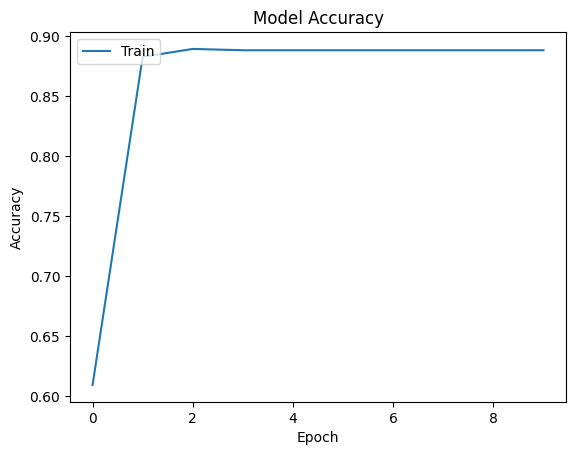

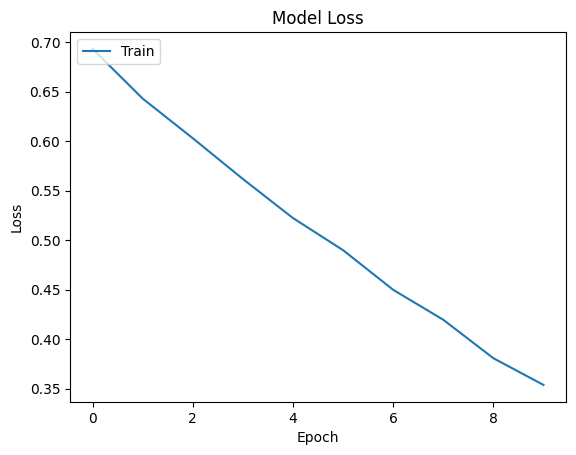

['loss', 'compile_metrics']
Model Compiled and Trained
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.5587 - loss: 0.9312
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8704 - loss: 0.2842
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9926 - loss: 0.0506
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9854 - loss: 0.0775
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9924 - loss: 0.0372
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9982 - loss: 0.0161
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9959 - loss: 0.0305
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9986 - loss: 0.0181
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9982 - loss: 0.0183
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9980 - loss: 0.0143


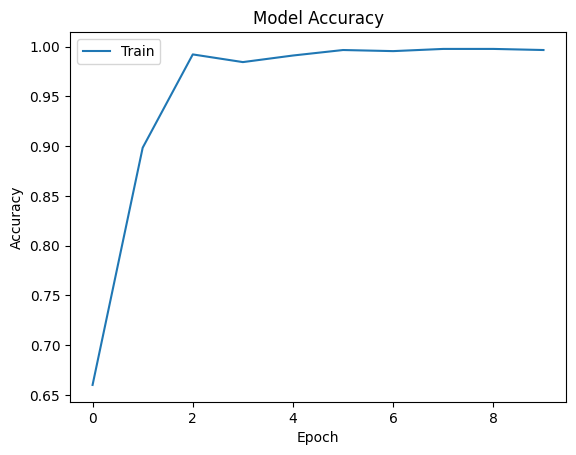

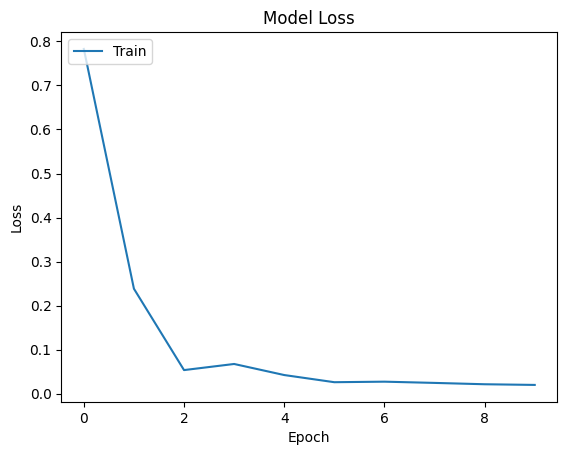

['loss', 'compile_metrics']
Model Compiled and Trained
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.4667 - loss: 0.6993
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5427 - loss: 0.6841
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.7032 - loss: 0.6655
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7969 - loss: 0.6495
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7860 - loss: 0.6337
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.7850 - loss: 0.6141
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8103 - loss: 0.5862
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8126 - loss: 0.5674
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7863 - loss: 0.5423
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.8611 - loss: 0.5079


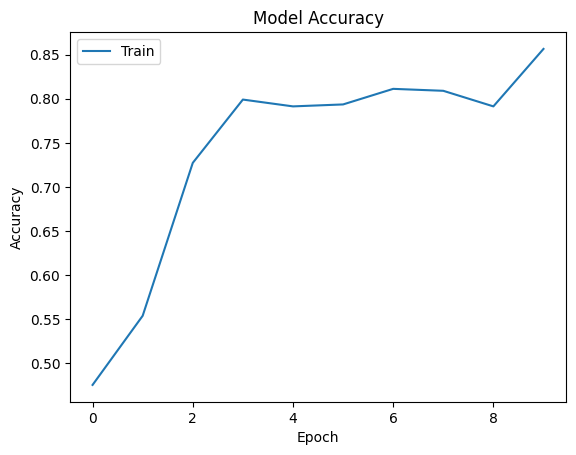

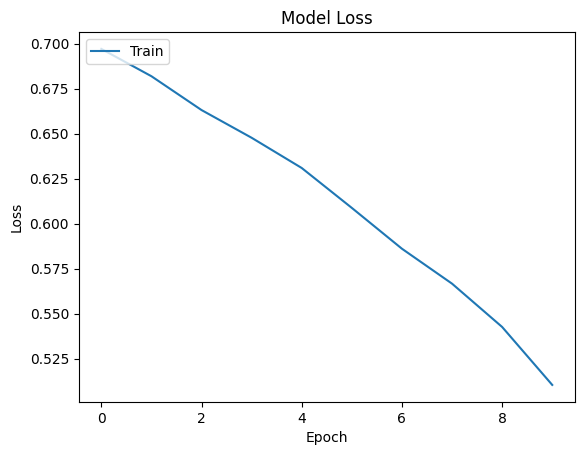

['loss', 'compile_metrics']
Model Compiled and Trained
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5417 - loss: 0.6916
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8313 - loss: 0.5743 
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8913 - loss: 0.4611 
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9034 - loss: 0.3784 
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9255 - loss: 0.2926 
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9482 - loss: 0.2185 
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9530 - loss: 0.1675 
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9749 - loss: 0.1145 
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9755 - loss: 0.0989 
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9818 - loss: 0.0724 


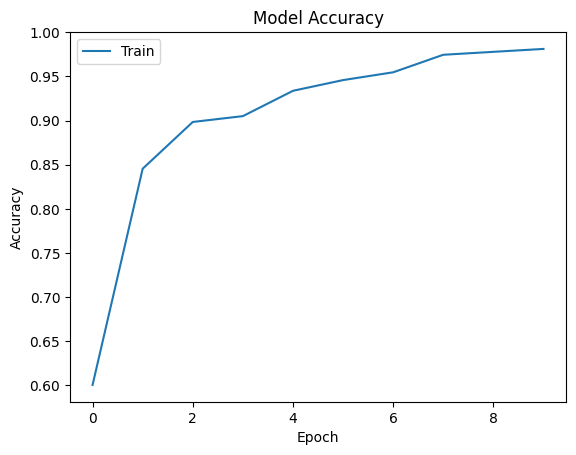

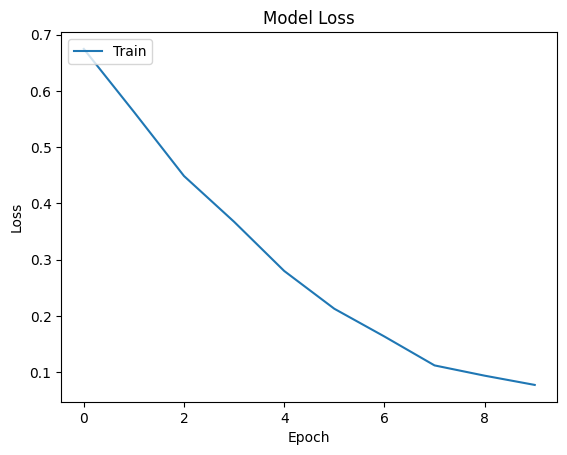

['loss', 'compile_metrics']
Model Compiled and Trained
Model Compiled and Trained
Model Compiled and Trained
Model Compiled and Trained
Model Compiled and Trained


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, LSTM, Conv1D, Dense, Dropout, Flatten, BatchNormalization

def GRU_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim, 1)),
        GRU(64),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

def LSTM_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim, 1)),
        LSTM(64),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

def CNN_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim, 1)),
        Conv1D(64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

def DNN_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model


model_gru = GRU_model(X_train.shape[1])
model_cnn = CNN_model(X_train.shape[1])
model_lstm = LSTM_model(X_train.shape[1])
model_dnn = DNN_model(X_train.shape[1])

model_svm = SVM()
model_lr = LR()
model_gd = GD()
model_knn = kNN()


model_gru = compile_train(model_gru,format_3d(X_train),y_train)  #quando treina novo modelo, ou retreina
model_cnn = compile_train(model_cnn,format_3d(X_train),y_train)
model_lstm = compile_train(model_lstm,format_3d(X_train),y_train)
model_dnn = compile_train(model_dnn,X_train,y_train)
model_svm = compile_train(model_svm,X_train,y_train,False)
model_lr = compile_train(model_lr,X_train,y_train,False)
model_gd = compile_train(model_gd,X_train,y_train,False)
model_knn = compile_train(model_knn,X_train,y_train,False)



# Testing CIC-DDoS2019 

In [26]:
results = pd.DataFrame(columns=['Method','Accuracy','Precision','Recall', 'F1_Score', 'Average','Normal_Detect_Rate','Atk_Detect_Rate'])

### GRU

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9552 - loss: 0.2776
[0.26881715655326843, 0.9714794754981995]

Accuracy
0.9714795008912656

Precision
0.9688473520249221

Recall
0.9978609625668449

F1 Score
0.9831401475237092

Average (acc, prec, rec, f1)
0.9803319907516854


<ipython-input-30-8b9178491ee4>:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, new_data], ignore_index=True)


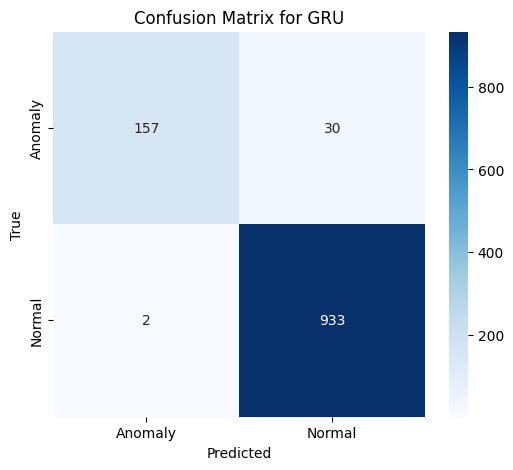

In [30]:
# Making predictions for GRU model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score



y_pred = model_gru.predict(format_3d(X_test))
y_pred = y_pred.round()

# Metrics calculation
acc, prec, rec, f1, avrg = testes(model_gru, format_3d(X_test), y_test, y_pred)

norm = tn / (tn + fp) if (tn + fp) > 0 else 0  # Normal_Detect_Rate = TN / (TN + FP)
atk = tp / (tp + fn) if (tp + fn) > 0 else 0
tn, fp, fn, tp = confusion_matrix(np.ravel(y_test),np.ravel(y_pred) ).ravel()
fp_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

# Replace append with concat
new_data = pd.DataFrame([{
    'Method': 'GRU', 'Accuracy': acc, 'Precision': prec, 'F1_Score': f1,
    'Recall': rec, 'Average': avrg, 'Normal_Detect_Rate': norm, 'Atk_Detect_Rate': atk,'false positive rate':fp_rate
}])

# Drop any empty or all-NA columns (if any)
new_data = new_data.dropna(axis=1, how='all')

# Concatenate with the results DataFrame
results = pd.concat([results, new_data], ignore_index=True)


# Plotting the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Anomaly', 'Normal'], yticklabels=[ 'Anomaly', 'Normal'])
plt.title('Confusion Matrix for GRU')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()





### CNN

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9818 - loss: 0.4337
[0.5353245735168457, 0.9500890970230103]

Accuracy
0.9500891265597148

Precision
0.9988649262202043

Recall
0.9411764705882353

F1 Score
0.9691629955947136

Average (acc, prec, rec, f1)
0.964823379740717


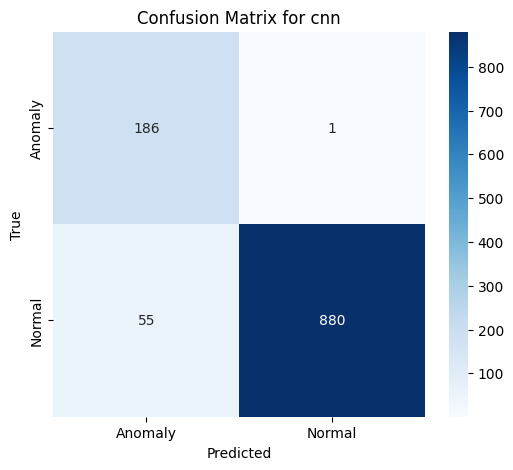

In [31]:
# Making predictions for CNN model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score




y_pred = model_cnn.predict(format_3d(X_test))
y_pred = y_pred.round()

# Metrics calculation
acc, prec, rec, f1, avrg = testes(model_cnn, format_3d(X_test), y_test, y_pred)

def test_normal_atk(y_test, y_pred):
    df = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})
    normal = df[df['y_test'] == 0].shape[0]
    atk = df[df['y_test'] == 1].shape[0]
    wrong = df[df['y_test'] != df['y_pred']]
    
    # Group wrong predictions by the true class
    wrong_counts = wrong.groupby('y_test').count()

    wrong_normal = wrong_counts.loc[0]['y_pred'] if 0 in wrong_counts.index else 0
    wrong_atk = wrong_counts.loc[1]['y_pred'] if 1 in wrong_counts.index else 0

    normal_detect_rate = (normal - wrong_normal) / normal if normal > 0 else 0
    atk_detect_rate = (atk - wrong_atk) / atk if atk > 0 else 0

    return normal_detect_rate, atk_detect_rate


tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
fp_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

# Replace append with concat
new_data = pd.DataFrame([{
    'Method': 'CNN', 'Accuracy': acc, 'Precision': prec, 'F1_Score': f1,
    'Recall': rec, 'Average': avrg, 'Normal_Detect_Rate': norm, 'Atk_Detect_Rate': atk,'false positive rate':fp_rate
}])

# Drop any empty or all-NA columns (if any)
new_data = new_data.dropna(axis=1, how='all')

# Concatenate with the results DataFrame
results = pd.concat([results, new_data], ignore_index=True)

# Plotting the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Anomaly', 'Normal'], yticklabels=[ 'Anomaly', 'Normal'])
plt.title('Confusion Matrix for cnn')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()




### LSTM

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9455 - loss: 0.4606
[0.4545699656009674, 0.9625668525695801]

Accuracy
0.9625668449197861

Precision
0.9588900308324769

Recall
0.9978609625668449

F1 Score
0.9779874213836478

Average (acc, prec, rec, f1)
0.9743263149256889


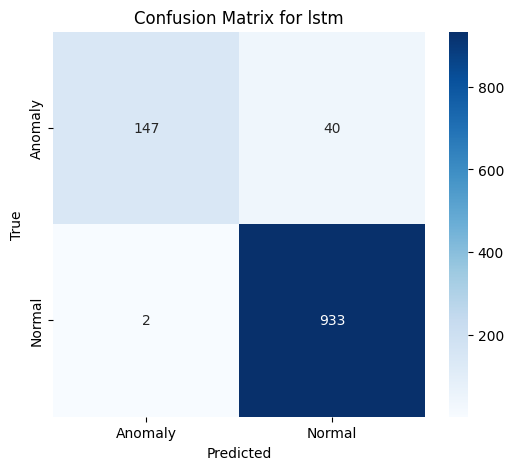

In [32]:
# Making predictions for LSTM model
y_pred = model_lstm.predict(format_3d(X_test))
y_pred = y_pred.round()

# Metrics calculation
acc, prec, rec, f1, avrg = testes(model_lstm, format_3d(X_test), y_test, y_pred)

norm, atk = test_normal_atk(np.ravel(y_test),np.ravel(y_pred))
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
fp_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

# Replace append with concat
new_data = pd.DataFrame([{
    'Method': 'LSTM', 'Accuracy': acc, 'Precision': prec, 'F1_Score': f1,
    'Recall': rec, 'Average': avrg, 'Normal_Detect_Rate': norm, 'Atk_Detect_Rate': atk,'false positive rate':fp_rate
}])

# Drop any empty or all-NA columns (if any)
new_data = new_data.dropna(axis=1, how='all')

# Concatenate with the results DataFrame
results = pd.concat([results, new_data], ignore_index=True)

# Plotting the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Anomaly', 'Normal'], yticklabels=[ 'Anomaly', 'Normal'])
plt.title('Confusion Matrix for lstm')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()




### DNN

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9955 - loss: 0.0284  
[0.04665330797433853, 0.9919785857200623]

Accuracy
0.9919786096256684

Precision
0.9989224137931034

Recall
0.9914438502673797

F1 Score
0.9951690821256038

Average (acc, prec, rec, f1)
0.9943784889529388


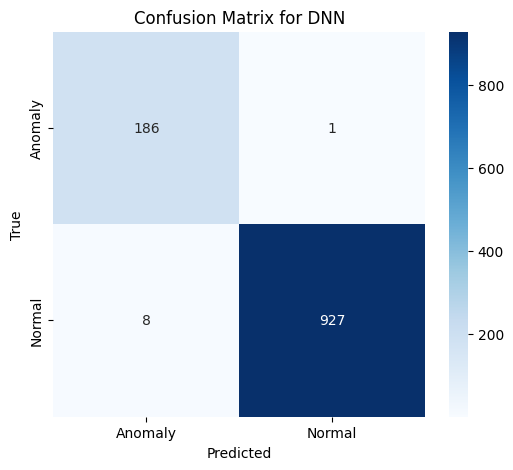

In [33]:
# Making predictions for DNN model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


y_pred = model_dnn.predict(X_test)
y_pred = y_pred.round()

# Metrics calculation
acc, prec, rec, f1, avrg = testes(model_dnn, X_test, y_test, y_pred)



y_test_flat = np.ravel(y_test)
y_pred_flat = np.ravel(y_pred)

norm, atk = test_normal_atk(y_test_flat, y_pred_flat)
tn, fp, fn, tp = confusion_matrix(y_test_flat, y_pred_flat).ravel()
fp_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

# Replace append with concat
new_data = pd.DataFrame([{
    'Method': 'DNN', 'Accuracy': acc, 'Precision': prec, 'F1_Score': f1,
    'Recall': rec, 'Average': avrg, 'Normal_Detect_Rate': norm, 'Atk_Detect_Rate': atk,'false positive rate':fp_rate
}])

# Drop any empty or all-NA columns (if any)
new_data = new_data.dropna(axis=1, how='all')

# Concatenate with the results DataFrame
results = pd.concat([results, new_data], ignore_index=True)

# Plotting the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Anomaly', 'Normal'], yticklabels=[ 'Anomaly', 'Normal'])
plt.title('Confusion Matrix for DNN')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()




### SVM


Accuracy
0.9946524064171123

Precision
0.9957310565635006

Recall
0.9978609625668449

F1 Score
0.9967948717948719

Average (acc, prec, rec, f1)
0.9962598243355824


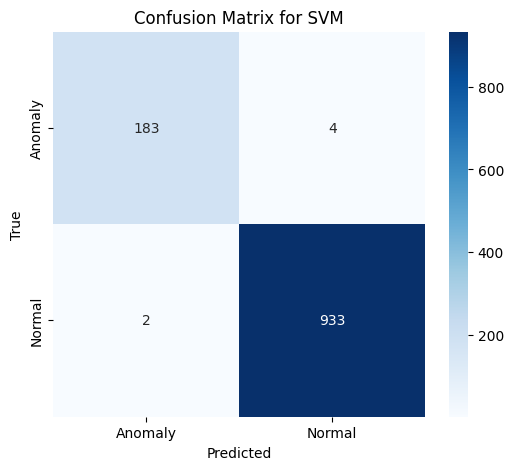

In [34]:
# Making predictions for SVM model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

y_pred = model_svm.predict(X_test)
y_pred = y_pred.round()

# Metrics calculation
acc, prec, rec, f1, avrg = testes(model_svm, X_test, y_test, y_pred, False)

norm, atk = test_normal_atk(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
fp_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

# Create the new data to append
new_data = pd.DataFrame([{
    'Method': 'SVM', 'Accuracy': acc, 'Precision': prec, 'F1_Score': f1,
    'Recall': rec, 'Average': avrg, 'Normal_Detect_Rate': norm, 'Atk_Detect_Rate': atk,'false positive rate':fp_rate
}])

# Drop any empty or all-NA columns (if any)
new_data = new_data.dropna(axis=1, how='all')

# Concatenate with the results DataFrame
results = pd.concat([results, new_data], ignore_index=True)

# Plotting the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Anomaly', 'Normal'], yticklabels=[ 'Anomaly', 'Normal'])
plt.title('Confusion Matrix for SVM')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()





### LR


Accuracy
0.9982174688057041

Precision
0.9989304812834224

Recall
0.9989304812834224

F1 Score
0.9989304812834224

Average (acc, prec, rec, f1)
0.9987522281639929


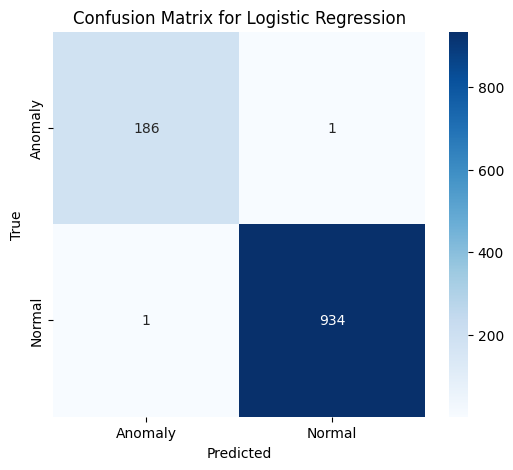

In [35]:
# Logistic Regression Prediction
y_pred_lr = model_lr.predict_proba(X_test)[:, 1]  # Get probabilities for class 1
y_pred_lr = (y_pred_lr > 0.5).astype(int)  # Apply threshold of 0.5

# Evaluate LR model
acc_lr, prec_lr, rec_lr, f1_lr, avrg_lr = testes(model_lr, X_test, y_test, y_pred_lr, False)

# Test normal vs. attack rate for LR
norm_lr, atk_lr = test_normal_atk(y_test, y_pred_lr)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
fp_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
# Store results for LR in the results DataFrame
results = pd.concat([results, pd.DataFrame([{'Method': 'LR',
                                             'Accuracy': acc_lr,
                                             'Precision': prec_lr, 
                                             'F1_Score': f1_lr,
                                             'Recall': rec_lr,
                                             'Average': avrg_lr, 
                                             'Normal_Detect_Rate': norm_lr,
                                             'Atk_Detect_Rate': atk_lr,
                                             'false positive rate':fp_rate
                                            }])], ignore_index=True)

# Plotting the confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Anomaly', 'Normal'], yticklabels=[ 'Anomaly', 'Normal'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()




### kNN


Accuracy
0.9964349376114082

Precision
0.9967982924226254

Recall
0.9989304812834224

F1 Score
0.9978632478632479

Average (acc, prec, rec, f1)
0.997506739795176


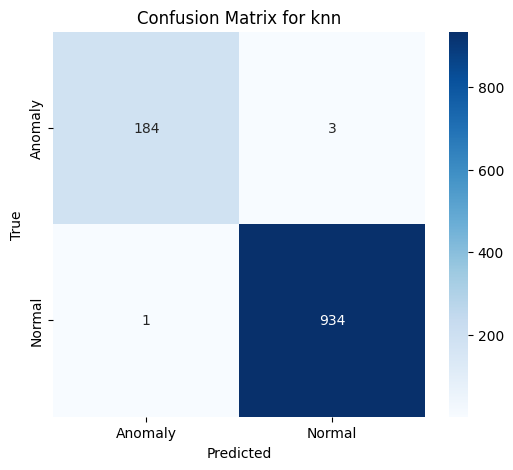

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

y_pred = model_knn.predict(X_test)

y_pred = y_pred.round()

acc, prec, rec, f1, avrg = testes(model_knn, X_test, y_test, y_pred, False)

norm, atk = test_normal_atk(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
fp_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

# Replace append with concat
results = pd.concat([results, pd.DataFrame([{'Method': 'kNN',
                                             'Accuracy': acc,
                                             'Precision': prec, 
                                             'F1_Score': f1,
                                             'Recall': rec,
                                             'Average': avrg, 
                                             'Normal_Detect_Rate': norm,
                                             'Atk_Detect_Rate': atk,
                                            'false positive rate':fp_rate}])], ignore_index=True)
# Plotting the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Anomaly', 'Normal'], yticklabels=[ 'Anomaly', 'Normal'])
plt.title('Confusion Matrix for knn')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()



# Discussion and Results

Showing the table 'results', containing the performance metrics outcomes for each method.

In [37]:
results

,Method,Accuracy,Precision,Recall,F1_Score,Average,Normal_Detect_Rate,Atk_Detect_Rate,false positive rate
0,GRU,0.971480,0.968847,0.997861,0.983140,0.980332,0.839572,0.997861,0.160428
1,CNN,0.950089,0.998865,0.941176,0.969163,0.964823,0.839572,0.997861,0.005348
2,LSTM,0.962567,0.958890,0.997861,0.977987,0.974326,0.786096,0.997861,0.213904
3,DNN,0.991979,0.998922,0.991444,0.995169,0.994378,0.994652,0.991444,0.005348
4,SVM,0.994652,0.995731,0.997861,0.996795,0.996260,0.978610,0.997861,0.021390
5,LR,0.998217,0.998930,0.998930,0.998930,0.998752,0.994652,0.998930,0.021390
6,kNN,0.996435,0.996798,0.998930,0.997863,0.997507,0.983957,0.998930,0.016043


**Classification Metrics:**
* Accuracy
* Precision
* Recall
* F1 Measure (F1 Score)

Showing performance outcomes of the methods: 
* GRU
* DNN
* SVM
* LR
* GB
* kNN

LSTM and CNN were separated for visualization improvement.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

In [ ]:
ax = sns.catplot(data=results.iloc[:,:5].query('Method != "LSTM" and Method != "CNN"'), col='Method', col_wrap=3, kind='bar', height=3, aspect=2)
ax.set(ylim=(0.99,1))
ax.set_xticklabels(rotation=45)
ax = ax


> As observed, the evaluated methods achieved good performance outcomes close to 1. As the evaluated methods achieved similar outcomes, a more specific analysis should be performed.

Showing results of the LSTM and CNN methods.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Confirm which methods are available in your results
print("Available methods:", results['Method'].unique())

#  Step 2: Filter only valid methods (update the list as needed)
valid_methods = ['GRU', 'DNN']  # Replace or add 'LSTM', 'CNN' if you have them
filtered = results[results['Method'].isin(valid_methods)]

#  Step 3: Melt the DataFrame for plotting
metrics = ['Accuracy', 'Precision', 'F1_Score', 'Recall']
plot_data = pd.melt(filtered[['Method'] + metrics], id_vars='Method', 
                    var_name='Metric', value_name='Score')

#  Step 4: Plot
ax = sns.catplot(data=plot_data, x='Metric', y='Score', col='Method',
                 kind='bar', height=3, aspect=2, col_wrap=3)

ax.set(ylim=(0.97, 1))  # Adjust as needed
for axes in ax.axes.flat:
    axes.set_xticklabels(axes.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()


> CNN and LSTM fared worse between the tested approaches. However, these methods achieved performance metrics above 97%, which is a relatively good outcome. 

**Average of the Metrics**

Plotting the Average of the previously mentioned performance metrics to summarize the method's results. 

In [ ]:
plt.figure(figsize=(12, 4))
ax = sns.barplot(data=results, y='Method', x='Average')
ax.set(xlim=(0.98, 1))
ax.set_title('Average of the Metrics', fontsize=18, loc='left')
# If you want to modify the x-tick labels, uncomment the line below and provide the desired labels
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45)  # Example for rotating labels
ax = ax
plt.show()


> As observed, on average, kNN fared slightly better compared to GB, LR, SVM, and GRU, which, in turn, achieved very similar results. However, these methods performed nearly 99.9%, which is considered a good classification outcome. 

**Detection rate of Normal and Attack flow records**

The following plot shows the results of each method for classifying normal and attack flow records.

In [ ]:
ax = sns.catplot(data=results[['Method', 'Normal_Detect_Rate', 'Atk_Detect_Rate']], col='Method', col_wrap=3, kind='bar', height=3, aspect=2)
ax.set(ylim=(0.97,1))
ax.set_xticklabels(rotation=45)
ax = ax


> kNN achieved the best classification outcomes. 

> GRU showed the most balanced approach regarding classifying normal and attack flows. 

> Although CNN achieved a relatively good classification of attacks, the classification of normal record flows was low compared to other methods. This result can explain the Accuracy rate of this method. This situation also occurs with the LSTM method, which achieved a good classification rate for normal flows and a low classification rate for attack ones. 